# Some Experiments to Understand how a Pytorch Optimizer works

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm

from soap_mods import SOAP

Let's generate a simple 1D regression problem

In [38]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)*np.sin(2*x)

And visualize it

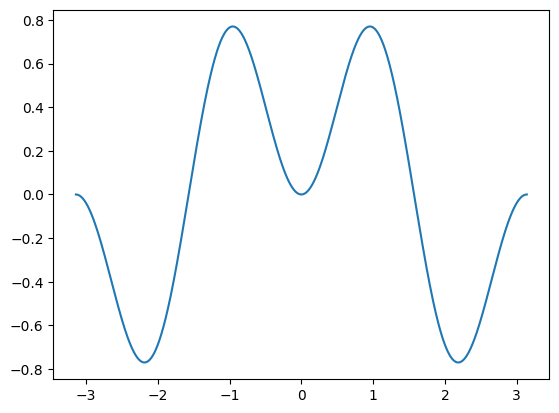

In [39]:
plt.plot(x, y)

Now let's create a simple NN model

In [40]:
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32, bias=True),
            nn.ReLU(),
            nn.Linear(32, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

Create the training and testing datasets, then create a training loop

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.reshape(-1, 1))
x_test = scaler.transform(x_test.reshape(-1, 1))

X_train = torch.from_numpy(x_train).float()
Y_train = torch.from_numpy(y_train).float().unsqueeze(1)
X_test = torch.from_numpy(x_test).float()
Y_test = torch.from_numpy(y_test).float().unsqueeze(1)

In [42]:
loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)
model = LinearNN()
criterion = nn.MSELoss()
optimiser = SOAP(model.parameters(), lr=0.001, precondition_1d=True)

epochs = 100

In [43]:
optimiser.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.001,
   'betas': (0.95, 0.95),
   'shampoo_beta': -1,
   'eps': 1e-08,
   'weight_decay': 0.01,
   'precondition_frequency': 10,
   'max_precond_dim': 10000,
   'merge_dims': False,
   'precondition_1d': True,
   'normalize_grads': False,
   'correct_bias': True,
   'params': [0, 1, 2, 3, 4, 5]}]}

In [44]:
pbar = tqdm(range(epochs), desc="Training",)
for epoch in pbar:
    epoch_loss = 0.0
    for x_batch, y_batch in loader:
        optimiser.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        # if epoch == 100:
        #     for name, param in model.named_parameters():
        #         if param.grad is not None:
        #             print(f"{name}: {param.grad}")
        optimiser.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    if (epoch) % 10 == 0:
        pbar.set_postfix(mse=f"{epoch_loss:.6f}")

Training: 100%|██████████| 100/100 [00:01<00:00, 50.52it/s, mse=nan]                   


Test the model

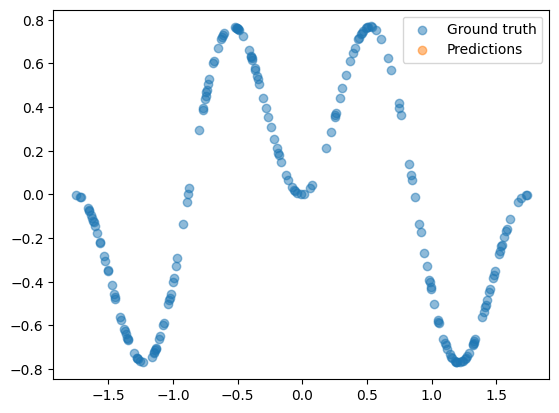

In [45]:
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze(1).numpy()

plt.scatter(x_test, y_test, label="Ground truth", alpha=0.5)
plt.scatter(x_test, preds, label="Predictions", alpha=0.5)
plt.legend()

## Optimizer data storage

In [47]:
optstate = optimiser.state_dict()

In [48]:
optstate['state'][0]['step']

2499

At each epoch, step is updated at every presentation of a batch
$$
steps = \frac{\# x_{test}}{\# batch} \times epochs
$$

In [49]:
optstate['state'][0].keys()

dict_keys(['step', 'exp_avg', 'exp_avg_sq', 'GG', 'Q', 'precondition_frequency', 'shampoo_beta'])

Adam keeps track of the exponentially averaged gradients and its square

In [50]:
optstate['param_groups'][0].keys()

dict_keys(['lr', 'betas', 'shampoo_beta', 'eps', 'weight_decay', 'precondition_frequency', 'max_precond_dim', 'merge_dims', 'precondition_1d', 'normalize_grads', 'correct_bias', 'params'])

param_groups is a list of dictionaries with one element.

In [51]:
optstate['param_groups'][0]

{'lr': 0.001,
 'betas': (0.95, 0.95),
 'shampoo_beta': -1,
 'eps': 1e-08,
 'weight_decay': 0.01,
 'precondition_frequency': 10,
 'max_precond_dim': 10000,
 'merge_dims': False,
 'precondition_1d': True,
 'normalize_grads': False,
 'correct_bias': True,
 'params': [0, 1, 2, 3, 4, 5]}

Now, what is params? Why its elements are the keys of 'state'?

In [52]:
print(model)
for p in optstate['param_groups'][0]['params']:
    print(optstate['state'][p]['exp_avg_sq'].shape)

LinearNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
torch.Size([32, 1])
torch.Size([32])
torch.Size([64, 32])
torch.Size([64])
torch.Size([1, 64])
torch.Size([1])


In [53]:
print(optimiser)

SOAP (
Parameter Group 0
    betas: (0.95, 0.95)
    correct_bias: True
    eps: 1e-08
    lr: 0.001
    max_precond_dim: 10000
    merge_dims: False
    normalize_grads: False
    precondition_1d: True
    precondition_frequency: 10
    shampoo_beta: -1
    weight_decay: 0.01
)


In [54]:
for param_group in optimiser.param_groups:
    for param in param_group['params']:
        print(param.shape)

torch.Size([32, 1])
torch.Size([32])
torch.Size([64, 32])
torch.Size([64])
torch.Size([1, 64])
torch.Size([1])


In [55]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name}: {param.grad.shape}")

net.0.weight: torch.Size([32, 1])
net.0.bias: torch.Size([32])
net.2.weight: torch.Size([64, 32])
net.2.bias: torch.Size([64])
net.4.weight: torch.Size([1, 64])
net.4.bias: torch.Size([1])


In [56]:
namedpars = list(model.named_parameters())

In [57]:
namedpars[2][1]

Parameter containing:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], requires_grad=True)

`params` enumerates the NN layers: state is kept for each layer in `optstate['state'][p]` where p is in params, e.g. for the first layer, the grandient, square gradient, preconditioners etc, are kept in the dictionary at `optstate['state'][0]`

## Preconditioning

Ok fine, now let's try to extract the preconditioners in the case of SOAP

In [58]:
if str(optimiser)[0:4] == "SOAP":
    print("This is a SOAP optimiser.\nYou can access the preconditioner.")
else:
    print("This is not a SOAP optimiser.")

This is a SOAP optimiser.
You can access the preconditioner.


In [59]:
print(model)
for p in optstate['param_groups'][0]['params']:
    for mat in optstate['state'][p]['Q']:
        if isinstance(mat, torch.Tensor):
            print(f"{p}: {mat.shape}")
        else:
            print(f"{p}: {mat}")

LinearNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
0: torch.Size([32, 32])
0: torch.Size([1, 1])
1: torch.Size([32, 32])
2: torch.Size([64, 64])
2: torch.Size([32, 32])
3: torch.Size([64, 64])
4: torch.Size([1, 1])
4: torch.Size([64, 64])
5: torch.Size([1, 1])


Ok, shape makes sense for the preconditioners. Bias layers have an empty list as a preconditioner... why?
Because `precodition_1d = False`, while if it is set to `True` also 1D gradients will be preconditioned, like the ones for bias

In [60]:
print(model)
for p in optstate['param_groups'][0]['params']:
    for mat in optstate['state'][p]['GG']:
        if isinstance(mat, torch.Tensor):
            print(f"{p}: {mat.shape}")
        else:
            print(f"{p}: {mat}")

LinearNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
0: torch.Size([32, 32])
0: torch.Size([1, 1])
1: torch.Size([32, 32])
2: torch.Size([64, 64])
2: torch.Size([32, 32])
3: torch.Size([64, 64])
4: torch.Size([1, 1])
4: torch.Size([64, 64])
5: torch.Size([1, 1])


A bit of experiments with projectors to get a gist of the preconditioning: projection is $G' = Q^T_L G Q_R$

In [61]:
v = torch.randn(3).unsqueeze_(1)
m = torch.randn(3, 2)
projector = torch.from_numpy(np.eye(3)[0:2,:]).float()

projecting a column vector of 3 elements to a 2-dimensional space and trying to obtain the same results with @ and tensordot

In [62]:
print(f"v:\n{v}")
print(f"projector:\n{projector}")
print(f"projected v (@):\n{projector @ v}")
print(f"projected v (tensordot):\n{torch.tensordot(projector, v, dims=1)}")

v:
tensor([[0.1389],
        [0.1251],
        [0.3993]])
projector:
tensor([[1., 0., 0.],
        [0., 1., 0.]])
projected v (@):
tensor([[0.1389],
        [0.1251]])
projected v (tensordot):
tensor([[0.1389],
        [0.1251]])


projecting a 3 $\times$ 2 matrix to a 2 $\times$ 2  matrices space

In [63]:
print(f"m:\n{m}")
print(f"projector:\n{projector}")
print(f"projected m:\n{projector @ m}")
print(f"projected m (tensordot):\n{torch.tensordot(projector, m, dims=([1], [0]))}")

m:
tensor([[-2.5834,  0.4672],
        [-0.9733, -1.4381],
        [ 0.6848, -0.1835]])
projector:
tensor([[1., 0., 0.],
        [0., 1., 0.]])
projected m:
tensor([[-2.5834,  0.4672],
        [-0.9733, -1.4381]])
projected m (tensordot):
tensor([[-2.5834,  0.4672],
        [-0.9733, -1.4381]])


In [64]:
torch.tensordot(m,m, dims = ([0], [0]))

tensor([[8.0900, 0.0671],
        [0.0671, 2.3200]])

In [65]:
L = m @ m.transpose(0,1)
R = m.transpose(0,1) @ m
Ql = (torch.linalg.eigh(L).eigenvectors).flip([1])
Qr = (torch.linalg.eigh(R).eigenvectors).flip([1])

In [66]:
(Ql.transpose(0,1) @ m) @ Qr

tensor([[-2.8444e+00,  1.1921e-07],
        [-1.7323e-07, -1.5229e+00],
        [ 5.8734e-08, -7.5194e-08]])

In [67]:
torch.linalg.svd(m)

torch.return_types.linalg_svd(
U=tensor([[-0.9062,  0.3265,  0.2686],
        [-0.3480, -0.9368, -0.0356],
        [ 0.2400, -0.1257,  0.9626]]),
S=tensor([2.8444, 1.5229]),
Vh=tensor([[ 0.9999,  0.0116],
        [-0.0116,  0.9999]]))

$G' = Q^T_L G Q_R$ Is computing a sungular value decomposition of G!
This is true for a single step, while in the real case, being G an exponential moving average, this is not exact.
[A similar algorithm is [GaLore](https://arxiv.org/abs/2403.03507)]

In [68]:
import itertools
idx = 0
[[*itertools.chain(range(idx), range(idx + 1, len(m.shape)))]] * 2

[[1], [1]]

In [69]:
torch.linalg.eigh(Ql)

torch.return_types.linalg_eigh(
eigenvalues=tensor([-1.2937, -1.0706, -0.4414]),
eigenvectors=tensor([[ 0.7336, -0.0989, -0.6723],
        [ 0.6097,  0.5328,  0.5869],
        [-0.3002,  0.8404, -0.4512]]))

In [70]:
torch.tensordot(m, m, dims=([[1], [1]]))

tensor([[ 6.8920,  1.8425, -1.8548],
        [ 1.8425,  3.0154, -0.4025],
        [-1.8548, -0.4025,  0.5026]])

In [71]:
m @ m.transpose(0,1)

tensor([[ 6.8920,  1.8425, -1.8548],
        [ 1.8425,  3.0154, -0.4025],
        [-1.8548, -0.4025,  0.5026]])

In [72]:
mp = m
for mat in [Ql, Qr]:
    mp = torch.tensordot(mp, mat, dims=([[0], [0]]))

mp

tensor([[-2.8444e+00,  1.1921e-07],
        [-1.7323e-07, -1.5229e+00],
        [ 5.8734e-08, -7.5194e-08]])

In [73]:
torch.flip(mp, [1])

tensor([[ 1.1921e-07, -2.8444e+00],
        [-1.5229e+00, -1.7323e-07],
        [-7.5194e-08,  5.8734e-08]])